# 05 — Explainability & a Traditional Points-Based Scorecard
### Lending Club Accepted Loans — Credit Risk (Default Prediction)

Credit risk is one of the few domains where explainability isn't optional polish — it's
often a regulatory requirement (in the US, the Equal Credit Opportunity Act / Regulation
B requires specific "adverse action" reasons when a consumer credit application is
declined). This notebook covers three related but distinct things:

1. **Global explainability** (SHAP) — what does the model rely on, in general?
2. **Local explainability** (SHAP, per-loan) — why did *this* applicant get *this*
   score, in language a non-technical stakeholder (or a regulator) can follow?
3. **The traditional alternative**: a WOE/points-based scorecard built from logistic
   regression. Many lenders — especially regulated banks — still deploy this instead of
   a black-box model specifically *because* it's self-explaining by construction. Worth
   knowing how to build one even when your final model is a gradient-boosted tree.

We explain the **uncalibrated** XGBoost model directly — SHAP's `TreeExplainer` reads
the tree structure, and calibration is a separate probability-scale correction applied
afterward that doesn't change which features drove the underlying score or their
relative importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')

TARGET = 'bad_flag'
feature_cols = [c for c in train_df.columns if c != TARGET]
X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_val, y_val = val_df[feature_cols], val_df[TARGET]

preprocess = joblib.load('preprocess.joblib')
raw_model = joblib.load('xgb_raw_model.joblib')

X_val_enc = preprocess.transform(X_val)
X_val_enc_df = pd.DataFrame(X_val_enc, columns=feature_cols, index=X_val.index)

## 1. Global explainability — what does the model rely on overall?

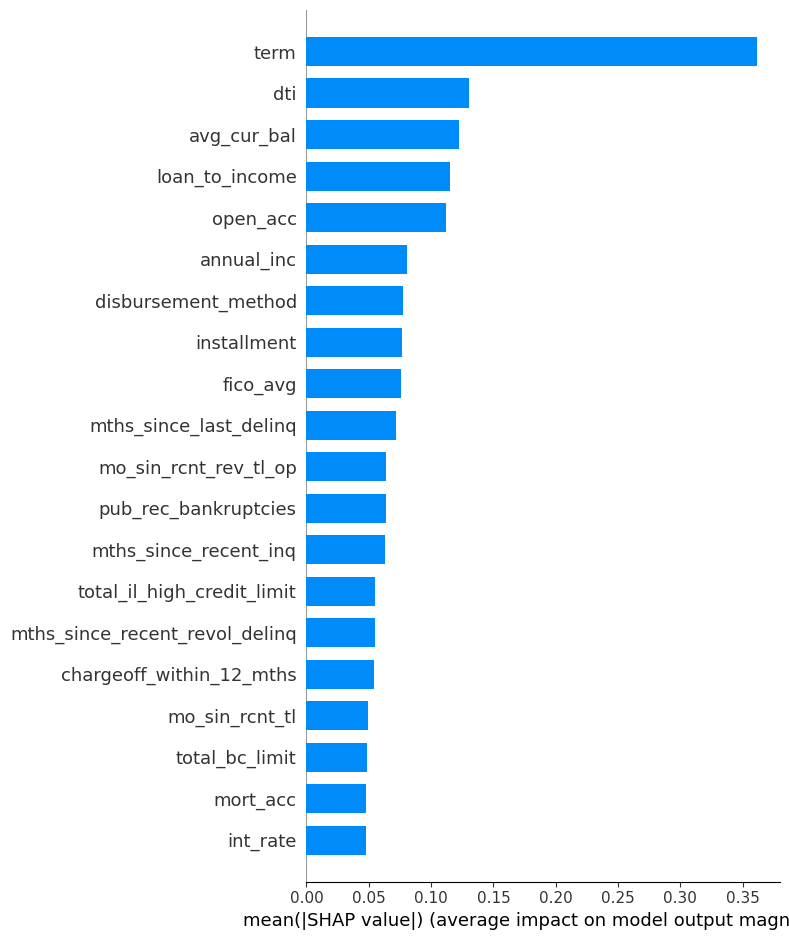

In [2]:
import shap

explainer = shap.TreeExplainer(raw_model)
sample = X_val_enc_df.sample(min(2000, len(X_val_enc_df)), random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar', show=False)
plt.tight_layout(); plt.show()

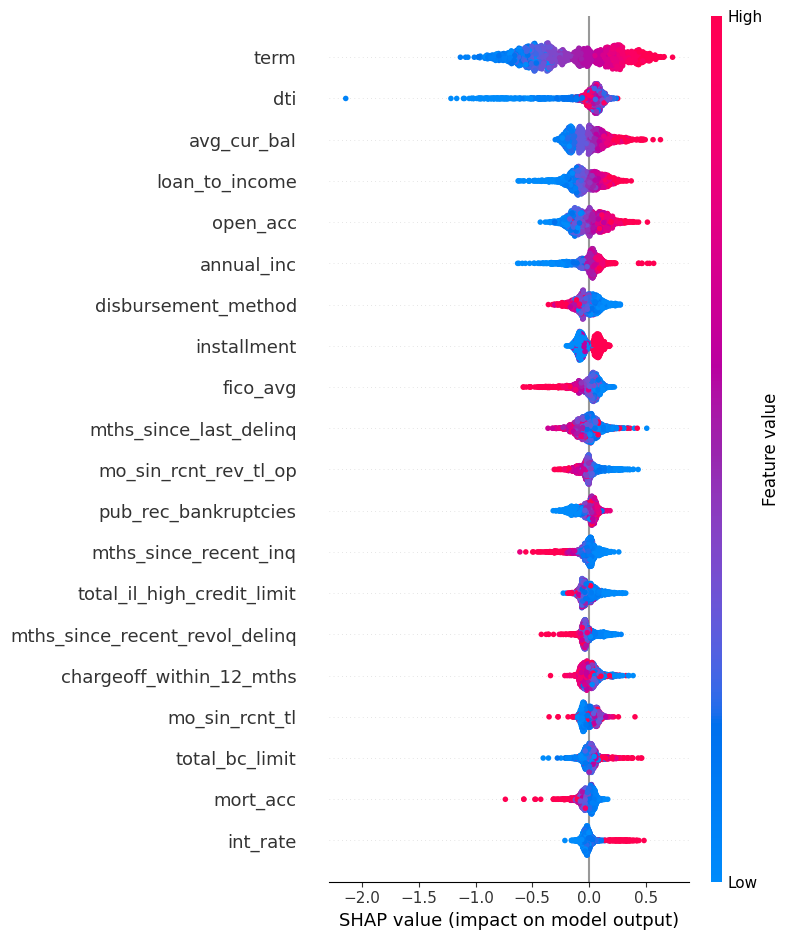

In [3]:
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout(); plt.show()

The beeswarm view adds direction, not just magnitude: for each feature, which end of
its value range (color) pushes the score up vs. down. Expect `sub_grade`/`int_rate` to
dominate — those features are highly predictive partly because they already encode Lending Club's own
risk assessment, not purely independent signal.

**A worked reminder on SHAP mechanics** (from earlier work on this project): for a tree
ensemble, SHAP values are additive in **log-odds space**, not probability space — the
sigmoid has to be applied to the *sum* of the base value and all contributions, never to
individual SHAP values one at a time. `shap.TreeExplainer` handles this correctly
internally.

## 2. Partial dependence — a complementary, model-level view

SHAP dependence plots (used already for `int_rate`, `sub_grade`, `term_num` in prior
work) show *actual data points*, including their interactions with other features.
Partial dependence plots (PDP) instead show the model's *average* marginal response —
useful as a second, simpler view, using `PartialDependenceDisplay` which is a
`scikit-learn`-native tool.

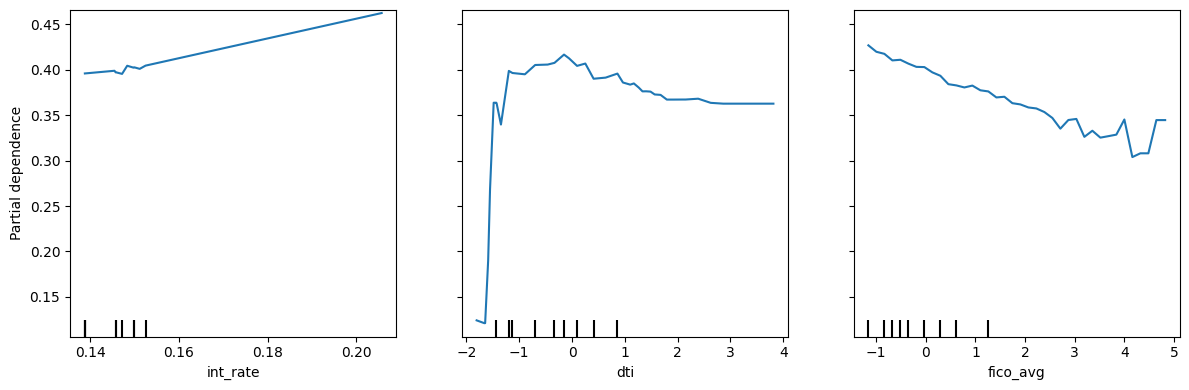

In [4]:
from sklearn.inspection import PartialDependenceDisplay

pdp_features = [f for f in ['int_rate', 'dti', 'fico_avg'] if f in feature_cols]
fig, ax = plt.subplots(figsize=(12,4))
PartialDependenceDisplay.from_estimator(
    raw_model, X_val_enc_df, features=pdp_features, ax=ax
)
plt.tight_layout(); plt.show()

## 3. Permutation importance — a model-agnostic cross-check

SHAP importance and permutation importance measure genuinely different things (SHAP:
average magnitude of contribution to individual predictions; permutation: how much
held-out performance degrades when a feature is shuffled). They usually broadly agree
on top features — a large disagreement is worth investigating (it often means two
correlated features are "sharing" credit differently between the two methods, not that
one method is simply wrong).

In [5]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    raw_model, X_val_enc, y_val, n_repeats=5, random_state=42,
    scoring='roc_auc', n_jobs=-1,
)
perm_df = pd.DataFrame({
    'feature': feature_cols,
    'perm_importance': perm.importances_mean,
}).sort_values('perm_importance', ascending=False)

shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

pd.merge(shap_importance, perm_df, on='feature').head(10)

,feature,mean_abs_shap,perm_importance
0,term,0.361909,0.037934
1,dti,0.130442,0.025981
2,avg_cur_bal,0.122035,0.009645
3,loan_to_income,0.115197,0.005999
4,open_acc,0.111898,0.007279
5,annual_inc,0.080439,0.004069
6,disbursement_method,0.077393,0.005437
7,installment,0.076753,0.004976
8,fico_avg,0.076235,0.004535
9,mths_since_last_delinq,0.072240,0.002551


## 4. Adverse-action reason codes

When an application is declined, ECOA/Reg B requires giving the applicant *specific*
reasons — not just "your score was too low." The practical implementation: take the
declined applicant's SHAP values, keep only the ones that pushed risk **up** (positive
contributions), and report the top few by magnitude as plain-language reasons. This
turns the explainability work above directly into a compliance deliverable, not just a
model-understanding exercise.

In [6]:
# A human-readable label per raw feature, for the reason-code text.
# In a real deployment this mapping would live in a shared config, reviewed by
# compliance/legal — not hardcoded in a notebook.
REASON_TEXT = {
    'int_rate': 'The interest rate assigned to this loan',
    'sub_grade': "The applicant's assigned credit sub-grade",
    'dti': "The applicant's debt-to-income ratio",
    'annual_inc': "The applicant's stated annual income",
    'revol_util': 'Revolving credit utilization',
    'fico_avg': 'Credit score (FICO estimate)',
    'delinq_2yrs': 'Number of delinquencies in the past 2 years',
    'pub_rec': 'Number of derogatory public records',
    'credit_history_years': 'Length of credit history',
    'loan_to_income': 'Loan amount relative to income',
    'open_acc': 'Number of open credit accounts',
    'mort_acc': 'Number of mortgage accounts',
}

def generate_reason_codes(shap_row, feature_names, top_n=4):
    contrib = pd.DataFrame({'feature': feature_names, 'shap': shap_row})
    contrib = contrib[contrib['shap'] > 0].sort_values('shap', ascending=False)
    reasons = []
    for feat in contrib['feature'].head(top_n):
        reasons.append(REASON_TEXT.get(feat, feat.replace('_', ' ').capitalize()))
    return reasons

# Demonstrate on the highest-risk applicant in the validation sample
scores = raw_model.predict_proba(X_val_enc)[:, 1]
i = int(np.argmax(scores))
row = X_val_enc_df.iloc[[i]]
row_shap = explainer.shap_values(row)[0]

print(f"Applicant risk score: {scores[i]:.3f}")
print("Adverse action reasons (highest risk-increasing factors):")
for r in generate_reason_codes(row_shap, feature_cols):
    print(' -', r)

Applicant risk score: 0.930
Adverse action reasons (highest risk-increasing factors):
 - Term
 - Avg cur bal
 - Loan amount relative to income
 - Percent bc gt 75


## 5. A traditional scorecard, built from WOE + logistic regression

Format: `Points = Offset + Factor × ln(odds)` — the same points-scaling convention
FICO uses (a fixed number of points to double the odds, "PDO"). We fit a small logistic
regression on WOE-transformed bins of a handful of strong, stable features (from the
`iv_table.csv` screening in notebook 02), then convert coefficients into a points table
per bin. The result: a scorecard a credit analyst can apply with a calculator, no model
object required — and one that's fully transparent to an auditor or regulator by
construction.

In [7]:
def compute_woe_table(frame, feature, target, bins=5):
    x = frame[feature]
    if x.dtype.kind in 'ifu' and x.nunique() > bins:
        binned = pd.qcut(x, q=bins, duplicates='drop')
    else:
        binned = x.astype(str)
    tmp = pd.DataFrame({'bin': binned, 'y': frame[target].values})
    g = tmp.groupby('bin', observed=True)['y'].agg(total='count', bad='sum')
    g['good'] = g['total'] - g['bad']
    tb, tg = g['bad'].sum(), g['good'].sum()
    g['dist_bad'] = (g['bad'] + 0.5) / (tb + 0.5 * len(g))
    g['dist_good'] = (g['good'] + 0.5) / (tg + 0.5 * len(g))
    g['woe'] = np.log(g['dist_good'] / g['dist_bad'])
    return g, binned

iv_table = pd.read_csv('iv_table.csv')
scorecard_features = (
    iv_table[iv_table['band'].isin(['medium', 'strong'])]
    .head(6)['feature'].tolist()
)
scorecard_features = [f for f in scorecard_features if f in train_df.columns]
print('Scorecard features (medium/strong IV):', scorecard_features)

woe_maps, train_woe = {}, pd.DataFrame(index=train_df.index)
for feat in scorecard_features:
    g, binned = compute_woe_table(train_df, feat, TARGET, bins=5)
    woe_maps[feat] = g
    train_woe[feat] = binned.map(g['woe']).astype(float)

from sklearn.linear_model import LogisticRegression
scorecard_lr = LogisticRegression()
scorecard_lr.fit(train_woe, train_df[TARGET])

pd.Series(scorecard_lr.coef_[0], index=scorecard_features).sort_values()

Scorecard features (medium/strong IV): ['sub_grade', 'int_rate', 'fico_avg']


sub_grade   -0.978240
fico_avg    -0.143092
int_rate     0.015724
dtype: float64

**Sign check before trusting this**: since our WOE convention is `ln(%good / %bad)`
(positive WOE = safer bin), a sound model predicting *bad* should show **negative**
coefficients throughout — higher WOE (safer) should pull the predicted bad-probability
down. If any coefficient comes out positive, that's not a subtlety to shrug off; it
usually means that bin's relationship with the target is genuinely non-monotonic and
the binning needs to be revisited (e.g. merge adjacent bins) before this feature goes
into a production scorecard.

In [8]:
PDO = 20            # points to double the odds
BASE_SCORE = 600
BASE_ODDS = 50       # odds of good:bad at the base score

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_feats = len(scorecard_features)
intercept_share = offset / n_feats - factor * scorecard_lr.intercept_[0] / n_feats

scorecard_tables = {}
for feat, coef in zip(scorecard_features, scorecard_lr.coef_[0]):
    g = woe_maps[feat].copy()
    g['points'] = intercept_share - factor * coef * g['woe']
    scorecard_tables[feat] = g[['total', 'bad', 'woe', 'points']].round(2)

for feat, tbl in scorecard_tables.items():
    print(f"\n--- {feat} ---")
    print(tbl)


--- sub_grade ---
     total   bad   woe  points
bin                           
A1   13741   367  1.85  231.31
A2   15191   633  1.39  218.33
A3   16593   815  1.21  213.48
A4   25126  1550  0.97  206.68
A5   29098  2245  0.73  199.90
B1   26949  2360  0.60  196.00
B2   31283  3027  0.49  192.90
B3   35853  3937  0.34  188.92
B4   34148  4199  0.22  185.31
B5   29995  4189  0.07  181.17
C1   30301  4576 -0.02  178.59
C2   29076  4807 -0.13  175.55
C3   26169  4755 -0.24  172.33
C4   23497  4615 -0.34  169.62
C5   21485  4387 -0.39  168.25
D1   17526  3755 -0.45  166.53
D2   15050  3431 -0.53  164.28
D3   13076  2972 -0.52  164.39
D4   11453  2789 -0.61  161.85
D5    9659  2425 -0.66  160.70
E1    6871  1859 -0.76  157.84
E2    6333  1767 -0.80  156.65
E3    4978  1418 -0.83  155.83
E4    4226  1268 -0.90  153.76
E5    3626  1121 -0.94  152.54
F1    2842   860 -0.91  153.41
F2    2092   703 -1.07  149.07
F3    1907   643 -1.07  148.92
F4    1389   509 -1.20  145.30
F5    1022   402 -1.

## Summary

- SHAP (global + local) explains the deployed XGBoost model directly; PDP and
  permutation importance provide model-native and model-agnostic cross-checks on the
  same conclusions.
- Reason-code generation turns SHAP output into an ECOA/Reg-B-style adverse action
  deliverable, ready to wrap into the deployment pipeline.
- A WOE/points scorecard was built from the strongest IV-screened features as the
  fully-transparent alternative many regulated lenders still require or prefer.

Next: **06 — monitoring, fairness, and deployment packaging.**